<hr>

# Chapter 03 — The Reinforcement Learning Loop
<hr>

**Theme**: turning an interactive problem into the standard language of reinforcement learning.

This course is notebook-first, where each chapter is represented as a notebook. Each notebook is designed to be read top-to-bottom and run as you go.

### What you will learn
- How the **agent–environment loop** organises an RL problem.
- How states, actions, rewards, policies, trajectories, and episodes fit together.
- Why immediate reward and long-term **return** are different.
- The difference between a state-value $V(s)$ and an state-action-value $Q(s,a)$.
- How different policies produce different behaviour and outcomes.

### Prereqs
- Chapters 01 and 02
- Python basics (functions, loops, dictionaries)
- Comfort reading short equations and simple plots

### Estimated time
- 45–60 minutes

<br>
<br>
<hr>
<br>
<br>


# 1. Introduction

Imagine an autonomous vacuum cleaner working in a small office after everyone has gone home. It needs to find dirty squares, move to them, clean them, and finish before its battery runs out.

A camera might help the robot **predict** where dirt is. But prediction alone does not tell it what to do next. Should it clean the square beneath it, move towards a nearby patch, or cross the room to avoid wasting time later? Each action changes the robot's location, the amount of dirt left, and the choices available next.

That makes this a sequential decision problem. The robot is judged not by one isolated move, but by the whole sequence:

- what it observes
- which action it chooses
- how the environment changes
- which reward it receives
- whether its later choices improve

Reinforcement learning gives us a compact language for describing this interaction. That language is the focus of this chapter.

Chapter 01 introduced acting under uncertainty. Chapter 02 showed why future consequences and value matter. We will now connect those ideas through the standard **RL loop**.

<br>
<br>
<hr>
<br>
<br>


# 2. Core Idea

### The RL loop in one sentence
**An agent observes a state, chooses an action, and receives a reward and a new state from the environment.**

```text
              action A_t
        ┌────────────────────►
     Agent                 Environment
        ◄────────────────────┘
       state S_{t+1}, reward R_{t+1}
```

The loop repeats:

1. At time $t$, the agent receives a **state** $S_t$.
2. The agent's **policy** selects an **action** $A_t$.
3. The environment responds with a **reward** $R_{t+1}$.
4. The environment moves to the next state $S_{t+1}$.
5. The process continues until the task ends or a time limit is reached.

### Core vocabulary

| Term | Plain-language meaning | Vacuum example |
|---|---|---|
| **Agent** | The decision-maker | The robot vacuum |
| **Environment** | Everything the agent interacts with | The room and its rules |
| **State** | Information used to make a decision | Robot position and remaining dirt |
| **Action** | A choice available to the agent | Move north, south, east, west, or clean |
| **Reward** | Immediate feedback after an action | Positive for removing dirt; negative for wasted time |
| **Policy** | A rule for choosing actions | Move towards the nearest dirty square |
| **Trajectory** | A sequence of states, actions, and rewards | One complete cleaning attempt |
| **Episode** | A trajectory with a defined ending | Clean all dirt or reach the step limit |

The reward is feedback for **one transition**. The agent's real objective is usually the total outcome over time.

<br>
<br>
<hr>
<br>
<br>


# 3. Worked Example

Consider this short vacuum episode. The robot starts at `(0, 0)`, and one dirty square is at `(0, 1)`.

| Time | State | Action | Reward | Next state |
|---:|---|---|---:|---|
| 0 | at `(0, 0)`, dirt at `(0, 1)` | east | `-0.1` | at `(0, 1)`, dirt remains |
| 1 | at `(0, 1)`, dirt at `(0, 1)` | clean | `+1.9` | at `(0, 1)`, no dirt |

The state must include both the robot's location and the remaining dirt. Position alone would not tell the agent whether `clean` is useful.

The trajectory can be written compactly as:

$$
S_0, A_0, R_1, S_1, A_1, R_2, S_2.
$$

### Reward versus return

The rewards are `[-0.1, 1.9]`. Their undiscounted sum is:

$$
-0.1 + 1.9 = 1.8.
$$

With discount factor $\gamma = 0.9$, the return from the start is:

$$
G_0 = R_1 + \gamma R_2
    = -0.1 + 0.9(1.9)
    = 1.61.
$$

Discounting makes rewards further in the future count less:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots
$$

A small return does not necessarily mean every action was bad. It summarises the consequences of the whole future trajectory from a particular time.

<br>
<br>
<hr>
<br>
<br>


# 4. Code Path A: Build the Vacuum World

Our environment is deliberately small and inspectable:

- a `3 × 3` grid
- two dirty squares
- movement actions plus `clean`
- a small cost for every action
- a larger reward for actually removing dirt
- an episode ending when all dirt is gone
- a step limit preventing an episode from running forever

The environment returns both `terminated` and `truncated`:

- **terminated** means the task's natural goal was reached
- **truncated** means an external limit stopped the episode

That distinction becomes important in practical RL libraries and experiments.


In [9]:
# If you're running this in a fresh environment, you only need numpy + matplotlib.
# Uncomment below as required:

# %pip install numpy
# %pip install matplotlib

from typing import Callable

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

ACTIONS = ("north", "south", "west", "east", "clean")
MOVES = {
    "north": (-1, 0),
    "south": (1, 0),
    "west": (0, -1),
    "east": (0, 1),
}

State = tuple[tuple[int, int], frozenset[tuple[int, int]]]


class VacuumGrid:
    '''A small deterministic robot-vacuum environment.'''

    def __init__(
        self,
        grid_size=3,
        start=(0, 0),
        dirt=((0, 2), (2, 2)),
        max_steps=20,
        step_cost=-0.1,
        clean_reward=2.0,
        invalid_penalty=-0.4,
    ):
        self.grid_size = int(grid_size)
        self.start = tuple(start)
        self.initial_dirt = frozenset(tuple(square) for square in dirt)
        self.max_steps = int(max_steps)
        self.step_cost = float(step_cost)
        self.clean_reward = float(clean_reward)
        self.invalid_penalty = float(invalid_penalty)
        self.rng = np.random.default_rng()
        self.position = self.start
        self.dirt = self.initial_dirt
        self.steps = 0

    def _state(self) -> State:
        return self.position, self.dirt

    def reset(self, seed=None) -> State:
        self.rng = np.random.default_rng(seed)
        self.position = self.start
        self.dirt = self.initial_dirt
        self.steps = 0
        return self._state()

    def step(self, action: str):
        if action not in ACTIONS:
            raise ValueError(f"Unknown action: {action}")

        reward = self.step_cost

        if action == "clean":
            if self.position in self.dirt:
                self.dirt = self.dirt - {self.position}
                reward += self.clean_reward
            else:
                reward += self.invalid_penalty
        else:
            d_row, d_col = MOVES[action]
            row, col = self.position
            candidate = (row + d_row, col + d_col)

            if (
                0 <= candidate[0] < self.grid_size
                and 0 <= candidate[1] < self.grid_size
            ):
                self.position = candidate
            else:
                reward += self.invalid_penalty

        self.steps += 1
        terminated = len(self.dirt) == 0
        truncated = self.steps >= self.max_steps and not terminated
        return self._state(), reward, terminated, truncated


env = VacuumGrid()
initial_state = env.reset(seed=7)
initial_state


((0, 0), frozenset({(0, 2), (2, 2)}))

## 4.1 Check the Environment by Hand

Before comparing policies, we should verify a few transitions. Small assertions are useful because environment mistakes can silently invalidate every later result.


In [10]:
test_env = VacuumGrid()

state = test_env.reset(seed=7)
assert state == ((0, 0), frozenset({(0, 2), (2, 2)}))

# Moving north from the top row is invalid, so position does not change.
state, reward, terminated, truncated = test_env.step("north")
assert state[0] == (0, 0)
assert np.isclose(reward, -0.5)
assert not terminated and not truncated

# A fresh environment can move east twice and remove the first dirt patch.
test_env.reset(seed=7)
test_env.step("east")
test_env.step("east")
state, reward, terminated, truncated = test_env.step("clean")
assert state[0] == (0, 2)
assert (0, 2) not in state[1]
assert np.isclose(reward, 1.9)
assert not terminated

print("Environment checks passed.")


Environment checks passed.


# 5. Baselines: Random and Oracle Policies

Before training an agent, we need reference points:

- The **random policy** tells us what happens without useful decision-making.
- The **oracle policy** already knows the room and always moves towards the nearest dirt. It represents a strong hand-written solution.

> **Reading guidance:** the next code cell is supporting machinery. Run it, and understand what each policy does at a high level, but you do not need to study every line. The oracle is not learning; it is a benchmark that uses knowledge we built in by hand.

The important distinction is:

```text
random policy  → no knowledge
oracle policy  → knowledge written by a programmer
learned policy → knowledge acquired from reward and experience
```


In [11]:
def random_policy(state: State, env: VacuumGrid, rng: np.random.Generator) -> str:
    '''Choose uniformly from all available actions.'''
    return str(rng.choice(ACTIONS))


def oracle_policy(
    state: State,
    env: VacuumGrid,
    rng: np.random.Generator,
) -> str:
    '''Clean current dirt; otherwise move towards the nearest dirty square.'''
    position, dirt = state

    if position in dirt:
        return "clean"

    nearest_distance = min(
        abs(position[0] - square[0]) + abs(position[1] - square[1])
        for square in dirt
    )
    nearest_targets = [
        square
        for square in sorted(dirt)
        if abs(position[0] - square[0]) + abs(position[1] - square[1])
        == nearest_distance
    ]
    target = nearest_targets[int(rng.integers(len(nearest_targets)))]

    row_delta = target[0] - position[0]
    col_delta = target[1] - position[1]
    useful_actions = []

    if row_delta < 0:
        useful_actions.append("north")
    elif row_delta > 0:
        useful_actions.append("south")

    if col_delta < 0:
        useful_actions.append("west")
    elif col_delta > 0:
        useful_actions.append("east")

    return useful_actions[int(rng.integers(len(useful_actions)))]


def discounted_return(rewards, gamma=0.9) -> float:
    '''Return R_1 + gamma R_2 + gamma^2 R_3 + ...'''
    total = 0.0
    discount = 1.0

    for reward in rewards:
        total += discount * reward
        discount *= gamma

    return float(total)


def run_episode(env, policy, gamma=0.9, seed=None):
    '''Run one episode and retain the complete trajectory.'''
    rng = np.random.default_rng(seed)
    state = env.reset(seed=seed)
    states = [state]
    actions = []
    rewards = []
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = policy(state, env, rng)
        state, reward, terminated, truncated = env.step(action)
        actions.append(action)
        rewards.append(reward)
        states.append(state)

    return {
        "states": states,
        "actions": actions,
        "rewards": rewards,
        "terminated": terminated,
        "truncated": truncated,
        "success": terminated,
        "episode_length": len(actions),
        "total_reward": float(np.sum(rewards)),
        "discounted_return": discounted_return(rewards, gamma),
    }


assert np.isclose(discounted_return([-0.1, 1.9], gamma=0.9), 1.61)
print("Baseline helpers ready.")


Baseline helpers ready.


# 6. Train a Policy with Q-learning

Now the agent will actually **learn from experience**.

We use tabular Q-learning. The table stores one number for every state-action pair:

$$
Q(s,a) \approx \text{how much future return action }a\text{ will produce in state }s.
$$

At first, every entry is zero. During training, the agent:

1. observes the current state
2. chooses an action, sometimes exploring randomly
3. receives a reward and next state
4. updates the value of the action it just took
5. repeats

The Q-learning update is:

$$
Q(S_t,A_t) \leftarrow Q(S_t,A_t)
+ \alpha\left[
R_{t+1} + \gamma\max_a Q(S_{t+1},a) - Q(S_t,A_t)
\right].
$$

The bracketed quantity is the **TD error**: the difference between the new target and the old estimate.

> **This is the key code block in the notebook.** Read the training loop carefully. It is intentionally kept small because it contains the complete cycle of acting, receiving reward, and learning.


In [13]:
from collections import defaultdict


def train_q_learning(
    n_episodes=3000,
    alpha=0.2,
    gamma=0.9,
    epsilon_start=1.0,
    epsilon_end=0.05,
    seed=7,
):
    '''Train action values by interacting with the vacuum environment.'''
    rng = np.random.default_rng(seed)
    q_values = defaultdict(lambda: np.zeros(len(ACTIONS)))
    episode_rewards = []
    episode_successes = []

    for episode in range(n_episodes):
        env = VacuumGrid()
        state = env.reset(seed=episode)
        epsilon = epsilon_start + (epsilon_end - epsilon_start) * (
            episode / max(1, n_episodes - 1)
        )
        total_reward = 0.0
        finished = False

        while not finished:
            # 1. Choose an action: explore sometimes, otherwise use current knowledge.
            if rng.random() < epsilon:
                action_index = int(rng.integers(len(ACTIONS)))
            else:
                action_index = int(np.argmax(q_values[state]))
            action = ACTIONS[action_index]

            # 2. Act and observe the reward and next state.
            next_state, reward, terminated, truncated = env.step(action)
            finished = terminated or truncated

            # 3. Build a target and update the value of the chosen action.
            best_next_value = 0.0 if finished else np.max(q_values[next_state])
            target = reward + gamma * best_next_value
            q_values[state][action_index] += alpha * (
                target - q_values[state][action_index]
            )

            state = next_state
            total_reward += reward

        episode_rewards.append(total_reward)
        episode_successes.append(float(terminated))

    return q_values, np.array(episode_rewards), np.array(episode_successes)


q_values, training_rewards, training_successes = train_q_learning()
print(f"Learned values for {len(q_values)} states.")


Learned values for 27 states.


## 6.1 What Changed During Training?

The model here is the Q-table. Training changes its numbers; it does not change the environment.

Early in training, exploration causes many poor episodes. As experience accumulates and `epsilon` falls, successful behaviour should become more common.

The raw reward from one episode is noisy, so we plot a rolling average. The success curve provides a second view of the same learning process.


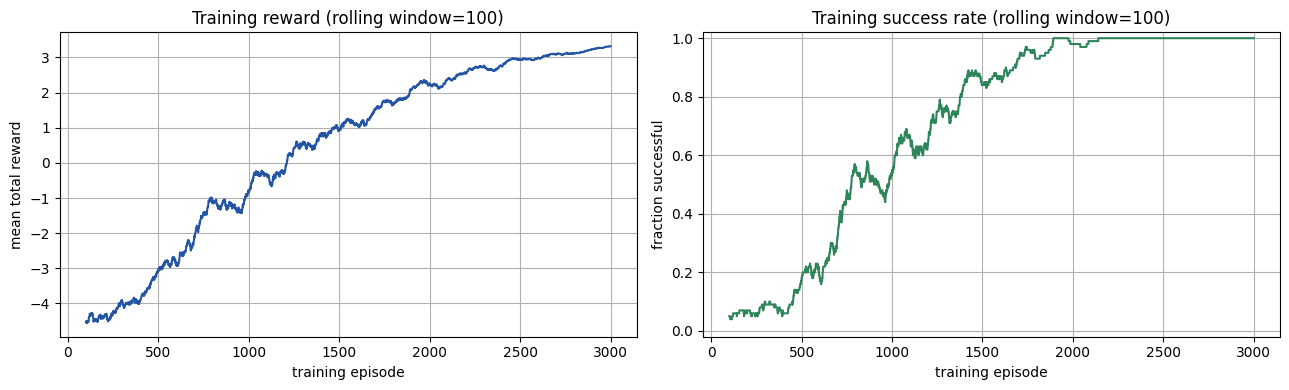

In [14]:
def rolling_mean(values, window=100):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode="valid")


window = 100
episodes = np.arange(window, len(training_rewards) + 1)

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].plot(episodes, rolling_mean(training_rewards, window), color="#2455a4")
axs[0].set_title(f"Training reward (rolling window={window})")
axs[0].set_xlabel("training episode")
axs[0].set_ylabel("mean total reward")

axs[1].plot(episodes, rolling_mean(training_successes, window), color="#2f855a")
axs[1].set_title(f"Training success rate (rolling window={window})")
axs[1].set_xlabel("training episode")
axs[1].set_ylabel("fraction successful")
axs[1].set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()


### What you should notice

- The early agent explores heavily, so reward and success are poor.
- The curves improve as the Q-table incorporates more experience.
- Learning is gradual: one reward does not immediately produce a good policy.
- The final policy is not copied from the oracle. It is obtained by choosing actions with the largest learned Q-values.

<br>
<br>
<hr>
<br>
<br>


# 7. Random vs Oracle vs Learned

We can now evaluate three different sources of behaviour:

- **random**: chooses without useful knowledge
- **oracle**: follows a rule written by a programmer
- **learned**: acts greedily from the trained Q-table

> **Reading guidance:** the next small function simply converts the Q-table into a policy. The visual comparisons are the important output.


In [15]:
def learned_policy(state: State, env: VacuumGrid, rng: np.random.Generator) -> str:
    '''Choose an action with the largest learned Q-value.'''
    return ACTIONS[int(np.argmax(q_values[state]))]


random_episode = run_episode(VacuumGrid(), random_policy, seed=4)
oracle_episode = run_episode(VacuumGrid(), oracle_policy, seed=4)
learned_episode = run_episode(VacuumGrid(), learned_policy, seed=4)


def episode_summary(name, episode):
    print(
        f"{name:8s} | success={episode['success']!s:5s} "
        f"| steps={episode['episode_length']:2d} "
        f"| reward={episode['total_reward']:5.2f} "
        f"| return={episode['discounted_return']:5.2f}"
    )


episode_summary("Random", random_episode)
episode_summary("Oracle", oracle_episode)
episode_summary("Learned", learned_episode)
print("\nLearned actions:", learned_episode["actions"])


Random   | success=False | steps=20 | reward=-3.20 | return=-2.20
Oracle   | success=True  | steps= 6 | reward= 3.40 | return= 2.33
Learned  | success=True  | steps= 6 | reward= 3.40 | return= 2.33

Learned actions: ['east', 'east', 'clean', 'south', 'south', 'clean']


## 7.1 Visualise the Three Trajectories

The numbers inside each circle show the order in which positions were visited. `D` marks the initial dirt locations.

The oracle gives us a useful ceiling for this simple deterministic room. The main question is whether learning discovers behaviour that approaches it.


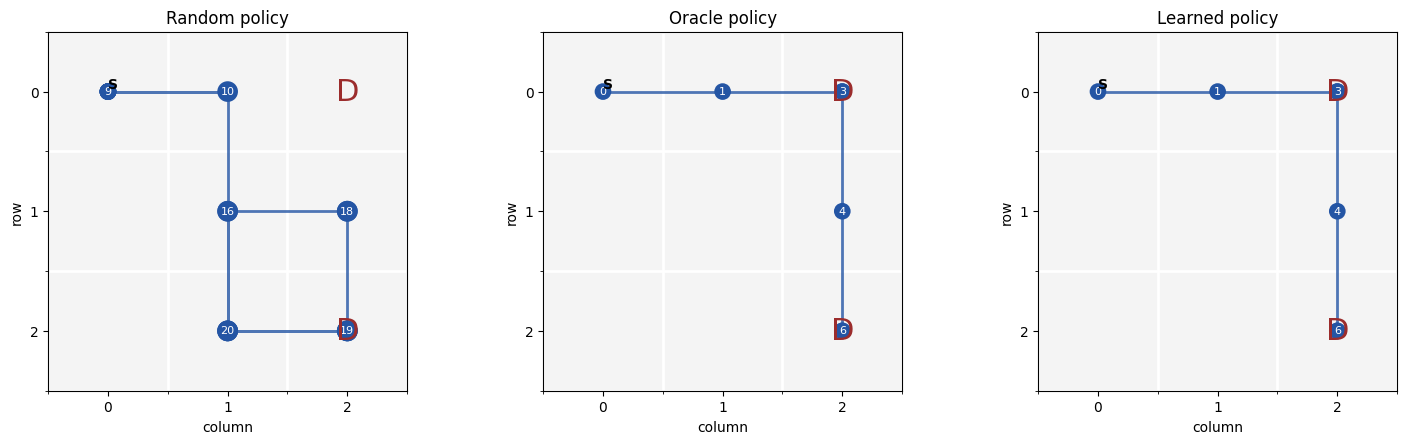

In [16]:
def plot_trajectory(ax, episode, env, title):
    '''Plot robot positions, dirt locations, and action order.'''
    background = np.zeros((env.grid_size, env.grid_size))
    ax.imshow(background, cmap=ListedColormap(["#f4f4f4"]), vmin=0, vmax=1)

    positions = [state[0] for state in episode["states"]]
    x = [position[1] for position in positions]
    y = [position[0] for position in positions]
    ax.plot(x, y, color="#2455a4", linewidth=2, alpha=0.8)

    for step, position in enumerate(positions):
        ax.text(
            position[1],
            position[0],
            str(step),
            ha="center",
            va="center",
            fontsize=8,
            color="white",
            bbox={"boxstyle": "circle", "facecolor": "#2455a4", "edgecolor": "none"},
        )

    for row, col in env.initial_dirt:
        ax.text(col, row, "D", ha="center", va="center", fontsize=22, color="#9b2c2c")

    ax.text(env.start[1], env.start[0], "S", ha="left", va="bottom", weight="bold")
    ax.set_title(title)
    ax.set_xticks(range(env.grid_size))
    ax.set_yticks(range(env.grid_size))
    ax.set_xticks(np.arange(-0.5, env.grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.grid_size, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.grid(which="major", visible=False)
    ax.set_xlabel("column")
    ax.set_ylabel("row")


fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
plot_trajectory(axs[0], random_episode, VacuumGrid(), "Random policy")
plot_trajectory(axs[1], oracle_episode, VacuumGrid(), "Oracle policy")
plot_trajectory(axs[2], learned_episode, VacuumGrid(), "Learned policy")
plt.tight_layout()
plt.show()


## 7.2 Compare Performance over Many Episodes

A single trajectory is easy to understand, but it is not enough for evaluation. We now repeat each policy over 200 episodes.

The evaluation helpers below collect the same four metrics for every policy. This is experiment plumbing rather than a new RL idea, so focus on the plots rather than reading every line.


In [17]:
def evaluate_policy(policy, n_episodes=200, gamma=0.9):
    episodes = [
        run_episode(VacuumGrid(), policy, gamma=gamma, seed=seed)
        for seed in range(n_episodes)
    ]
    return {
        "episodes": episodes,
        "success_rate": np.mean([episode["success"] for episode in episodes]),
        "mean_length": np.mean([episode["episode_length"] for episode in episodes]),
        "mean_reward": np.mean([episode["total_reward"] for episode in episodes]),
        "mean_return": np.mean([episode["discounted_return"] for episode in episodes]),
    }


policy_results = {
    "Random": evaluate_policy(random_policy),
    "Oracle": evaluate_policy(oracle_policy),
    "Learned": evaluate_policy(learned_policy),
}

for name, results in policy_results.items():
    print(
        f"{name:8s} | success={results['success_rate']:.1%} "
        f"| mean steps={results['mean_length']:.2f} "
        f"| mean reward={results['mean_reward']:.2f} "
        f"| mean return={results['mean_return']:.2f}"
    )

assert policy_results["Learned"]["success_rate"] > policy_results["Random"]["success_rate"]


Random   | success=4.0% | mean steps=19.75 | mean reward=-4.81 | mean return=-2.26
Oracle   | success=100.0% | mean steps=6.00 | mean reward=3.40 | mean return=2.33
Learned  | success=100.0% | mean steps=6.00 | mean reward=3.40 | mean return=2.33


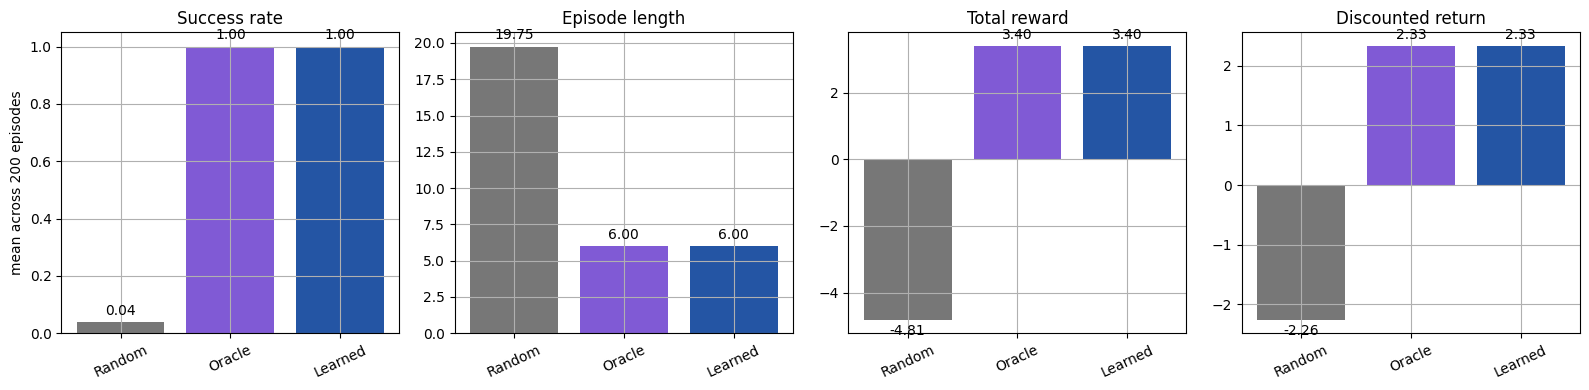

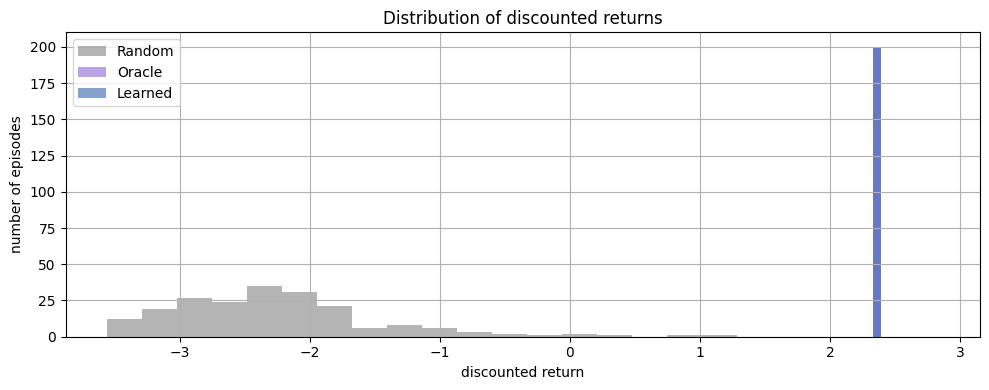

In [18]:
metric_specs = [
    ("Success rate", "success_rate"),
    ("Episode length", "mean_length"),
    ("Total reward", "mean_reward"),
    ("Discounted return", "mean_return"),
]
names = list(policy_results)
colours = ["#777777", "#805ad5", "#2455a4"]

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, key) in zip(axs, metric_specs):
    values = [policy_results[name][key] for name in names]
    bars = ax.bar(names, values, color=colours)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=25)
    ax.bar_label(bars, fmt="%.2f", padding=3)

axs[0].set_ylabel("mean across 200 episodes")
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 4))
for name, colour in zip(names, colours):
    returns = [
        episode["discounted_return"]
        for episode in policy_results[name]["episodes"]
    ]
    ax.hist(returns, bins=18, alpha=0.55, label=name, color=colour)

ax.set_title("Distribution of discounted returns")
ax.set_xlabel("discounted return")
ax.set_ylabel("number of episodes")
ax.legend()
plt.tight_layout()
plt.show()


### Interpreting the visual comparison

- Random behaviour produces low and variable returns.
- The oracle is efficient because it starts with complete task knowledge.
- The learned policy begins with no task-specific rule but improves through reward.
- In this small deterministic environment, Q-learning can approach the oracle.
- Training and evaluation are different: training updates the Q-table; evaluation freezes it and measures the resulting policy.

<br>
<br>
<hr>
<br>
<br>


# 8. Code Path B: Implement Discounted Return

The function below is small, but it captures one of the most important quantities in RL.

### Exercise

Delete the body of `discounted_return_exercise(...)` and recreate it yourself.

For rewards `[r_1, r_2, ..., r_T]`, compute:

$$
G_0 = \sum_{k=0}^{T-1}\gamma^k r_{k+1}.
$$

Use the assertions as a quick check. A solution is included at the bottom of the notebook.


In [19]:
def discounted_return_exercise(rewards, gamma=0.9) -> float:
    '''Compute a discounted return from a sequence of rewards.'''
    total = 0.0
    discount = 1.0

    # Exercise: recreate these four lines without calling discounted_return().
    for reward in rewards:
        total += discount * reward
        discount *= gamma

    return float(total)


assert np.isclose(discounted_return_exercise([2.0], gamma=0.9), 2.0)
assert np.isclose(discounted_return_exercise([1.0, 1.0, 1.0], gamma=0.5), 1.75)
assert np.isclose(discounted_return_exercise([-0.1, 1.9], gamma=0.9), 1.61)
print("Discounted-return checks passed.")


Discounted-return checks passed.


# 9. From Return to Value

A return belongs to one realised trajectory. A **value function** describes what we expect across possible future trajectories under a policy.

### State-value

$$
V^\pi(s) = \mathbb{E}_\pi[G_t \mid S_t=s]
$$

In plain English: if the agent starts in state $s$ and follows policy $\pi$, what return should it expect?

For the vacuum:

- a state with one nearby dirty square is likely more valuable than one with distant dirt
- the same physical location can have different value depending on which squares remain dirty
- value depends on the policy; a capable policy can make a state more promising

### Action-value

$$
Q^\pi(s,a) = \mathbb{E}_\pi[G_t \mid S_t=s, A_t=a]
$$

In plain English: what return should the agent expect if it takes action $a$ in state $s$, then follows policy $\pi$?

At a dirty square, `clean` should have a higher action-value than walking away under our reward design. Chapter 02 showed several ways values can be estimated. Our Q-learning agent used action-values directly: it improved its policy by choosing the action with the largest learned Q-value.

### A common mistake

Reward, return, and value are related but not interchangeable:

- **reward**: feedback from one transition
- **return**: accumulated future rewards in one trajectory
- **value**: expected return from a state or state-action pair

<br>
<br>
<hr>
<br>
<br>


# 10. A Light Preview of Markov Decision Processes

An **MDP**, or Markov decision process, is a standard mathematical model for the loop we have just implemented. Its main ingredients are:

- states $\mathcal{S}$
- actions $\mathcal{A}$
- transition dynamics
- rewards
- discount factor $\gamma$

The **Markov idea** says that the current state should contain the information needed to predict what happens next, given the next action.

That explains why our vacuum state contains:

```text
(robot position, remaining dirt)
```

If we stored only the robot position, the same recorded state could sometimes be dirty and sometimes clean. The effect of the `clean` action would then depend on hidden history. Including remaining dirt makes the state description more useful.

This does not mean every real problem gives us a perfect Markov state. Sensors can be incomplete, and important information can be hidden. We will later study partial observability. The next chapter will treat MDPs, transitions, and optimality more formally.

<br>
<br>
<hr>
<br>
<br>


# 11. Reward Design Caution

Suppose we accidentally reward the robot every time it issues the `clean` command:

```python
if action == "clean":
    reward += 2.0
```

The robot could then collect reward by repeatedly cleaning an already-clean square. It would maximise the written reward without completing the intended task.

Our environment instead rewards **removing actual dirt**:

```python
if action == "clean" and position in remaining_dirt:
    reward += 2.0
```

This small distinction illustrates a large practical problem: an agent optimises the objective we specify, not the intention in our heads.

Reward design is therefore part of defining the problem, not cosmetic decoration. Later chapters will revisit reward shaping, specification gaming, constraints, and safety in more depth.

<br>
<br>
<hr>
<br>
<br>


# 12. Diving Deeper

This section makes the notation more precise. You can skip it without affecting your ability to follow the next chapter.

### Policy notation

A stochastic policy is commonly written:

$$
\pi(a \mid s) = \Pr(A_t=a \mid S_t=s).
$$

It assigns a probability to each action in a state. Our random policy assigns probability $1/5$ to every action. The oracle is nearly deterministic, while the learned evaluation policy greedily selects the largest Q-value.

### Episodic and continuing tasks

The vacuum is **episodic** because each cleaning attempt has an ending. Other tasks continue indefinitely:

- controlling a data centre
- managing an inventory system
- serving recommendations

Continuing tasks need careful definitions of long-run performance. Discounted return is one common choice; average reward is another.

### Termination and truncation

These endings have different meanings:

- termination follows from the task itself
- truncation is imposed externally, often through a time limit

Treating a time limit as if it were a natural terminal state can bias value estimates. This becomes important when implementing learning algorithms.

### If you want to go deeper

- Sutton & Barto (2018), Chapter 3
- David Silver's first RL lecture on MDPs
- Gymnasium documentation on the `terminated` and `truncated` API

<br>
<br>
<hr>
<br>
<br>


# 13. Knowledge Check

### Tier 1: concept checks (5–10 minutes)

1. What is the difference between the oracle and learned policies?
2. Which three lines of the Q-learning loop correspond to acting, observing, and learning?
3. Why does the learned policy sometimes choose random actions during training?
4. What is the difference between an immediate reward and a return?
5. What is the difference between $V(s)$ and $Q(s,a)$?
6. Why should training and evaluation be kept separate?

### Tier 2: small coding change (15–30 minutes)

Choose one:

- Reduce training to 200 episodes. How do the learning curves and final policy change?
- Set `epsilon_end = 0.5`. What happens when the agent keeps exploring heavily?
- Try `gamma = 0.5` and `gamma = 0.99`. How does valuing the future affect learning?
- Increase the movement cost from `-0.1` to `-0.3`.

State your prediction before running the experiment.

### Tier 3: extension (30–60 minutes)

Extend the environment with one of:

- a battery level that falls after every action
- an obstacle the robot cannot cross
- a third dirty square in a larger grid

Retrain Q-learning and update the oracle. Compare random, oracle, and learned policies again. Explain why your new state representation is or is not Markov.

<br>
<br>
<hr>
<br>
<br>


# 14. Takeaways

- The RL loop connects an agent, its policy, actions, rewards, and changing states.
- A random policy, a programmed oracle, and a learned policy obtain their behaviour in different ways.
- Q-learning improves action-values from reward and experience.
- The essential learning cycle is: choose an action, observe a transition, build a target, and update an estimate.
- Training curves show whether behaviour improves; frozen-policy evaluation measures the final result.
- Immediate reward is not the same as return or value.
- $V(s)$ evaluates a state, while $Q(s,a)$ evaluates an action in a state.
- Visualising trajectories and return distributions can reveal behaviour hidden by a single average.

### Common pitfalls

- calling a hand-written policy a trained model
- becoming distracted by environment plumbing instead of the learning loop
- evaluating on the same episodes while the policy is still changing
- confusing reward with return or value
- assuming one successful trajectory proves that learning worked

<br>
<br>
<hr>
<br>
<br>

# 15. What's Next

- Next notebook: **Markov decision processes and optimality**, where we will formalise transition dynamics, policies, value functions, and optimal behaviour.
- Suggested reading: Sutton & Barto (2018), Chapters 3 and 6.

<br>
<br>
<hr>
<br>
<br>


In [11]:
######################################################################
######################## ANSWERS BELOW ###############################
######################################################################
######################## ANSWERS BELOW ###############################
######################################################################
######################## ANSWERS BELOW ###############################
######################################################################


## Answer to the Discounted Return Exercise

```python
def discounted_return_exercise(rewards, gamma=0.9) -> float:
    total = 0.0
    discount = 1.0

    for reward in rewards:
        total += discount * reward
        discount *= gamma

    return float(total)
```

<hr style="border: none; border-top: 2px dashed #999; margin: 24px 0;">


## Answers to Concept Checks

### 1. What is the difference between the oracle and learned policies?

The oracle contains a strategy written directly by a programmer. The learned policy begins without that strategy and acquires action-values by interacting with the environment and receiving rewards.

### 2. Which lines correspond to acting, observing, and learning?

Action selection chooses `action_index`. `env.step(action)` produces the next state and reward. The assignment to `q_values[state][action_index]` performs learning.

### 3. Why explore during training?

Without exploration, early arbitrary estimates could make the agent repeat the same actions and never discover better alternatives.

### 4. What is the difference between reward and return?

A reward is immediate feedback after one transition. A return combines future rewards, usually with discounting.

### 5. What is the difference between $V(s)$ and $Q(s,a)$?

$V(s)$ is expected return from a state under a policy. $Q(s,a)$ is expected return after taking a particular action in that state and then continuing.

### 6. Why separate training and evaluation?

During training the policy changes and explores, so its results mix learning behaviour with final performance. Evaluation freezes the learned values and measures the resulting policy consistently.
